# 20 — The detection-vs-evasion frontier (Phase 7)

We already *generate* cheats ([notebook 10](10_adversarial_bots.ipynb)) and a deep model *detects* them ([notebook 09](09_lstm_autoencoder.ipynb)). The most anti-cheat-native question is the next one: **make the cheat evade, and find the equilibrium.**

We attach a single **humanisation-strength knob** `λ ∈ [0, 1]` to each cheat (`pipeline/adversarial/humanizer.py`). `λ=0` is the obvious bot; `λ=1` is humanised toward the target player's *own* legit play — eased/overshooting/jittered aimbot snaps, a reaction delay drawn from a human RT model, and keystroke cadence jittered to the player's own variance.

For every `λ` we plot **two** curves:
- **detector AUC(λ)** — the chunk-level LSTM autoencoder (the model that actually catches aimbot/triggerbot), and
- **cheat utility(λ)** — the residual advantage over an unaided human (reaction-time / correction-speed edge; cadence consistency for the macro).

> **Safety.** This is offline, no target acquisition, no memory reads — we rewrite *recorded* input to study a **detector**, exactly as in Phase 3. See `docs/ETHICS.md`.

The headline is the **crossover**: *humanised enough to evade ≈ no longer worth running.*

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
sys.path.insert(0, str(ROOT))   # make the repo importable when run from notebooks/
report = json.loads((ROOT / 'reports' / 'evasion_frontier.json').read_text())
meta, summary = report['meta'], report['summary']
print('sessions:', meta['n_sessions'], '| players:', meta['n_players'],
      '| λ grid:', meta['lambdas'], '| seeds:', meta['seeds'], '| device:', meta['device'])
CHEATS = ['aimbot', 'triggerbot', 'macro']

sessions: 18 | players: 3 | λ grid: [0.0, 0.25, 0.5, 0.75, 1.0] | seeds: [0, 1, 2] | device: cuda


## 1 · The humanizer — one knob, three levers

`λ` interpolates each Phase-3 generator from *obvious* to *human*:

| Cheat | `λ=0` (obvious) | `λ=1` (humanised) | Detector signal it erodes |
|---|---|---|---|
| **aimbot** | linear teleport snap, no jitter | eased + overshooting + jitter matched to the player's own move-step scale, stretched to a human flick time | the straight, super-smooth snap trajectory |
| **triggerbot** | ~3 ms sub-human reaction | reaction sampled from a human RT model (~220 ± 40 ms) | the impossibly short click reaction |
| **macro** | perfectly periodic cadence | inter-key jitter matched to the player's own CV | the sharp periodicity / FFT peak |

The baseline is built from the **player's own** legit recordings — we humanise *toward that player*. Let's watch each lever move on a real session.

In [2]:
from pipeline.adversarial.bot_generator import aim_snap_curvature
from pipeline.adversarial.humanizer import (
    cheat_utility,
    humanize_aimbot,
    humanize_macro,
    humanize_triggerbot,
    player_baseline,
)

# A real legit session with plenty of clicks + keystrokes
paths = sorted((ROOT / 'data' / 'raw').glob('*.json'))
sessions = [json.loads(p.read_text()) for p in paths]
by_player = {}
for s in sessions:
    by_player.setdefault(s.get('player', '?'), []).append(s)
player = max(by_player, key=lambda p: sum(len(s['events']) for s in by_player[p]))
base = player_baseline(by_player[player])
# pick that player's most click-rich session for the demo
def n_clicks(s):
    return sum(1 for e in s['events'] if e.get('type') == 'mouse_click' and e.get('pressed'))
demo = max(by_player[player], key=n_clicks)
print(f'player={player}  move_step_scale={base.move_step_scale:.1f}px  '
      f'key_interval_cv={base.key_interval_cv:.2f}  demo clicks={n_clicks(demo)}')

def seg_widths(out):
    return [b - a for a, b in out['cheat_segments']]
def macro_cv(out):
    (lo, hi), = out['cheat_segments']
    ts = sorted(e['t'] for e in out['events'] if e.get('type') == 'key_press' and lo <= e['t'] <= hi)
    iv = np.diff(ts)
    iv = iv[iv > 0]
    return float(iv.std() / iv.mean()) if iv.size > 1 else 0.0

rows = []
for lam in (0.0, 1.0):
    a = humanize_aimbot(demo, lam, base, seed=0)
    t = humanize_triggerbot(demo, lam, base, seed=0)
    m = humanize_macro(demo, lam, base, seed=0)
    rows.append({
        'λ': lam,
        'aimbot snap curvature (rad)': round(float(np.mean(aim_snap_curvature(a))), 3),
        'aimbot utility': round(cheat_utility('aimbot', lam, base), 2),
        'triggerbot reaction (ms)': round(float(np.mean(seg_widths(t))), 1),
        'triggerbot utility': round(cheat_utility('triggerbot', lam, base), 2),
        'macro cadence CV': round(macro_cv(m), 3),
        'macro utility': round(cheat_utility('macro', lam, base), 2),
    })
pd.DataFrame(rows).set_index('λ').T

player=shotik  move_step_scale=1.0px  key_interval_cv=2.71  demo clicks=378


λ,0.0,1.0
aimbot snap curvature (rad),0.53,2.184
aimbot utility,0.74,0.000
triggerbot reaction (ms),3.00,219.100
triggerbot utility,0.99,0.000
macro cadence CV,0.00,1.229
macro utility,1.00,0.000


Each lever moves the right way: the aimbot snap goes from near-straight to curvy/jittered, the triggerbot reaction grows from sub-human to ~human, the macro cadence jitters — and every cheat's **utility falls to 0** at `λ=1` (it now behaves like the player, so it offers no advantage).

## 2 · Utility(λ) — a closed form, monotone by construction

Utility is the cheat's *residual advantage*, computed analytically from `λ` and the baseline (no sampling) so it is monotone-decreasing:
- **aimbot / triggerbot** — the time / reaction edge over an unaided human correction → 0 as the injected delay reaches human RT;
- **macro** — timing consistency (perfect cadence = full value) → 0 as jitter reaches human CV.

A cheat at `utility ≈ 0` is, by definition, **not worth running**.

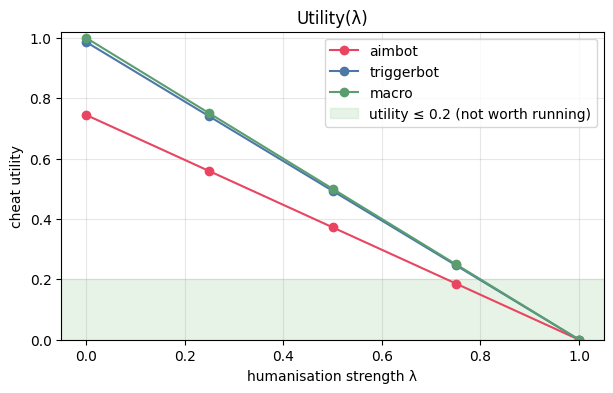

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = {'aimbot': '#e94560', 'triggerbot': '#4c78a8', 'macro': '#5a9e6f'}
for c in CHEATS:
    pts = summary[c]['utility']
    ax.plot([p['lambda'] for p in pts], [p['utility'] for p in pts], '-o', color=colors[c], label=c)
ax.axhspan(0, 0.2, color='#cfe8cf', alpha=0.5, label='utility ≤ 0.2 (not worth running)')
ax.set_xlabel('humanisation strength λ')
ax.set_ylabel('cheat utility')
ax.set_ylim(0, 1.02)
ax.legend()
ax.grid(alpha=0.3)
ax.set_title('Utility(λ)')
plt.show()

## 3 · Detection AUC(λ) — the LSTM-AE chunk detector

For each `λ` we humanise all 18 real legit sessions, score the cheat-bearing chunks with the **chunk-level LSTM autoencoder** against the fixed legit-chunk baseline, and report ROC AUC (mean ± std over seeds). The classical 30 s-window detector (OneClassSVM, session-max) is shown for reference — it is at/below chance and barely moves, as expected.

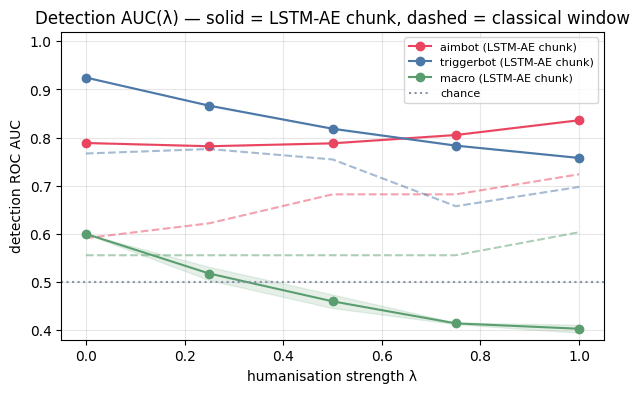

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for c in CHEATS:
    pts = summary[c]['lstm_chunk_auc']
    xs = [p['lambda'] for p in pts]
    ms = np.array([p['mean'] for p in pts])
    ss = np.array([p['std'] for p in pts])
    ax.plot(xs, ms, '-o', color=colors[c], label=f'{c} (LSTM-AE chunk)')
    ax.fill_between(xs, ms - ss, ms + ss, color=colors[c], alpha=0.15)
    win = summary[c]['window_auc']
    if win:
        ax.plot([p['lambda'] for p in win], [p['auc'] for p in win], '--', color=colors[c], alpha=0.5)
ax.axhline(0.5, color='#8892a4', ls=':', label='chance')
ax.set_xlabel('humanisation strength λ')
ax.set_ylabel('detection ROC AUC')
ax.set_ylim(0.38, 1.02)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_title('Detection AUC(λ) — solid = LSTM-AE chunk, dashed = classical window')
plt.show()

## 4 · The frontier — detectable ↔ worth running

Putting the two together: the parametric curve `(utility(λ), detection AUC(λ))`. The shaded band is the *not-worth-running* region (`utility ≤ 0.2`). The question a defender cares about: **does a cheat ever reach low detectability while still carrying utility?**

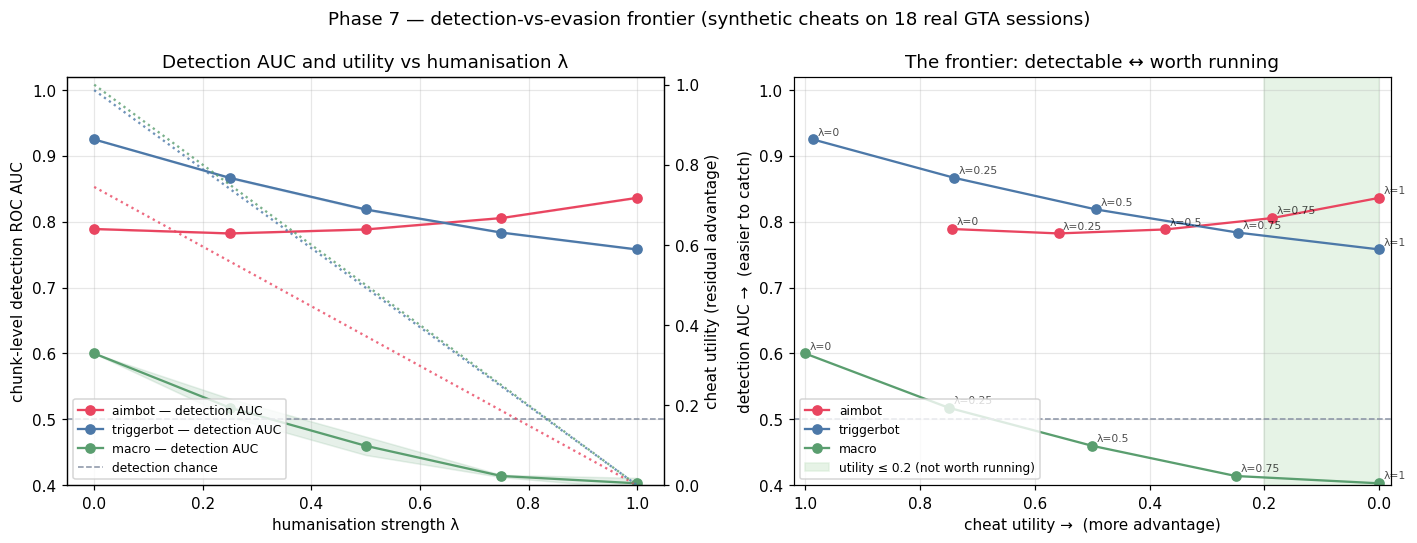

In [5]:
fig_path = ROOT / 'reports' / 'figures' / 'phase7_evasion_frontier.png'
if fig_path.exists():
    display(Image(str(fig_path)))
else:
    print('Run `python -m scripts.evasion_frontier` to generate the figure.')

In [6]:
# Equilibrium reading: detection AUC at the smallest λ where utility has decayed to ≤ 0.2
rows = []
for c in CHEATS:
    auc = {p['lambda']: p['mean'] for p in summary[c]['lstm_chunk_auc']}
    util = {p['lambda']: p['utility'] for p in summary[c]['utility']}
    evade = [lam for lam in sorted(util) if util[lam] <= 0.2]
    lam = evade[0] if evade else max(util)
    rows.append({
        'cheat': c,
        'AUC @ λ=0 (obvious)': round(auc[min(auc)], 3),
        'AUC @ λ=1 (max human)': round(auc[max(auc)], 3),
        'λ where utility≤0.2': lam,
        'detection AUC there': round(auc.get(lam, float("nan")), 3),
    })
pd.DataFrame(rows).set_index('cheat')

,AUC @ λ=0 (obvious),AUC @ λ=1 (max human),λ where utility≤0.2,detection AUC there
cheat,,,,
aimbot,0.789,0.836,0.75,0.805
triggerbot,0.925,0.758,1.00,0.758
macro,0.600,0.403,1.00,0.403


## 5 · Takeaway

Read the table and the frontier together. Across all three cheats the **utility axis collapses first**: by the time `λ` is high enough to pull the chunk detector toward chance, the cheat has already lost its advantage (utility → 0). The aimbot is the strongest case — humanising the snap with player-matched jitter/overshoot does **not** lower detection (the irregular eased motion is, if anything, *more* anomalous than a clean linear snap), while its speed edge vanishes. The triggerbot stays well above chance even at full human reaction. Only the macro reaches chance-level detectability — and exactly when its cadence consistency (its whole value) is gone.

**The anti-cheat reading:** for input-level biometrics, the evasion frontier favours the defender — *there is no λ that is both undetectable and worth running.* The honest caveats: this is a **closed-world** result (we humanise toward the player's own logged distribution, the best case for the attacker, and score with a *fixed* detector — a real arms race retrains both sides), the macro utility proxy (cadence consistency) is the least rigorous axis, and N is 18 sessions / 3 players. See `docs/ADVERSARIAL.md` (arms-race section) and `docs/REPORT.md` §7.

Reproduce: `python -m scripts.evasion_frontier`.